In [5]:
import pandas as pd
import matplotlib.pyplot as plt


In [6]:
csv_file = r'C:\Users\playe\Documents\Trabajos\TFG-RAG-VDB\src\Resulsts\resultados_rag_50.csv'
df_50 = pd.read_csv(csv_file)
csv_file = r'C:\Users\playe\Documents\Trabajos\TFG-RAG-VDB\src\Resulsts\resultados_rag_500.csv'
df_500 = pd.read_csv(csv_file)
csv_file = r'C:\Users\playe\Documents\Trabajos\TFG-RAG-VDB\src\Resulsts\resultados_rag_1000_2.csv'
df_1000 = pd.read_csv(csv_file)
csv_file = r'C:\Users\playe\Documents\Trabajos\TFG-RAG-VDB\src\Resulsts\resultados_rag_4000.csv'
df_4000 = pd.read_csv(csv_file)

import numpy as np
from scipy import stats

# Reemplaza con tus arrays de datos reales
# data_50, data_500, data_1000, data_4000

# 1. Comparación de Varianzas (No paramétrico / Robusto)
stat_levene, p_levene = stats.levene(df_500['Nota_Correctness'], df_1000['Nota_Correctness'], df_4000['Nota_Correctness'], center='median')
stat_fligner, p_fligner = stats.fligner(df_500['Nota_Correctness'], df_1000['Nota_Correctness'], df_4000['Nota_Correctness'])

print(f"Test de Levene (500 vs 1000 vs 4000): p-value = {p_levene:.4f}")
print(f"Test de Fligner-Killeen: p-value = {p_fligner:.4f}")

# 2. Distancia de Wasserstein (Mide la diferencia de forma entre distribuciones)
w_50_vs_4k = stats.wasserstein_distance(df_50['Nota_Correctness'], df_4000['Nota_Correctness'])
w_500_vs_4k = stats.wasserstein_distance(df_500['Nota_Correctness'], df_4000['Nota_Correctness'])
w_1000_vs_4k = stats.wasserstein_distance(df_1000['Nota_Correctness'], df_4000['Nota_Correctness'])

print(f"Distancia Wasserstein N=50 vs N=4000:   {w_50_vs_4k:.5f}")
print(f"Distancia Wasserstein N=500 vs N=4000:  {w_500_vs_4k:.5f}")
print(f"Distancia Wasserstein N=1000 vs N=4000: {w_1000_vs_4k:.5f}")

# 3. Estabilidad de los Estadísticos Clave
for n_name, data in [("N=500", df_500['Nota_Correctness']), ("N=1000", df_1000['Nota_Correctness']), ("N=4000", df_4000['Nota_Correctness'])]:
    print(f"{n_name} -> Media: {np.mean(data):.3f} | Desv: {np.std(data):.3f} | P90: {np.percentile(data, 90):.3f}")

Test de Levene (500 vs 1000 vs 4000): p-value = 0.7108
Test de Fligner-Killeen: p-value = 0.2310
Distancia Wasserstein N=50 vs N=4000:   0.06139
Distancia Wasserstein N=500 vs N=4000:  0.01487
Distancia Wasserstein N=1000 vs N=4000: 0.00460
N=500 -> Media: 0.647 | Desv: 0.228 | P90: 0.849
N=1000 -> Media: 0.660 | Desv: 0.232 | P90: 0.853
N=4000 -> Media: 0.660 | Desv: 0.229 | P90: 0.849


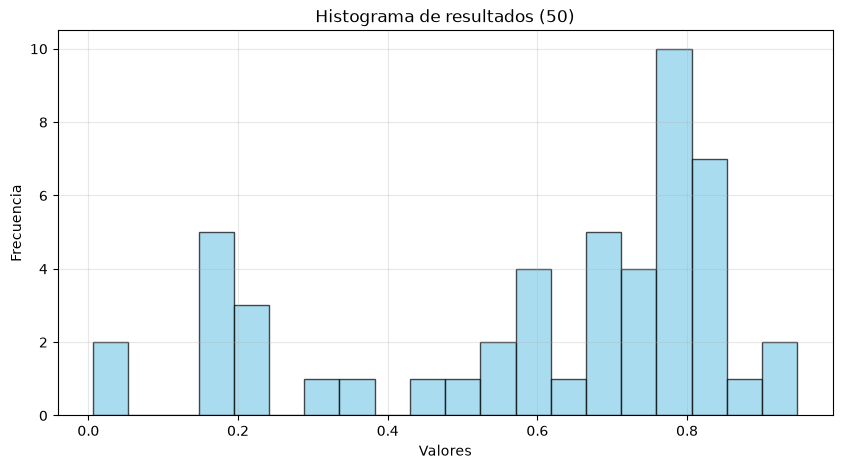

In [7]:
csv_file = r'C:\Users\playe\Documents\Trabajos\TFG-RAG-VDB\src\Resulsts\resultados_rag_50.csv'
df = pd.read_csv(csv_file)
fig, ax = plt.subplots(figsize=(10, 5))
ax.hist(df['Nota_Correctness'], bins=20, color='skyblue', edgecolor='black', alpha=0.7)
ax.set_xlabel('Valores')
ax.set_ylabel('Frecuencia')
ax.set_title('Histograma de resultados (50)')
ax.grid(True, alpha=0.3)
#fig.savefig('Histogram_50.png', dpi=300, bbox_inches='tight')
plt.show()



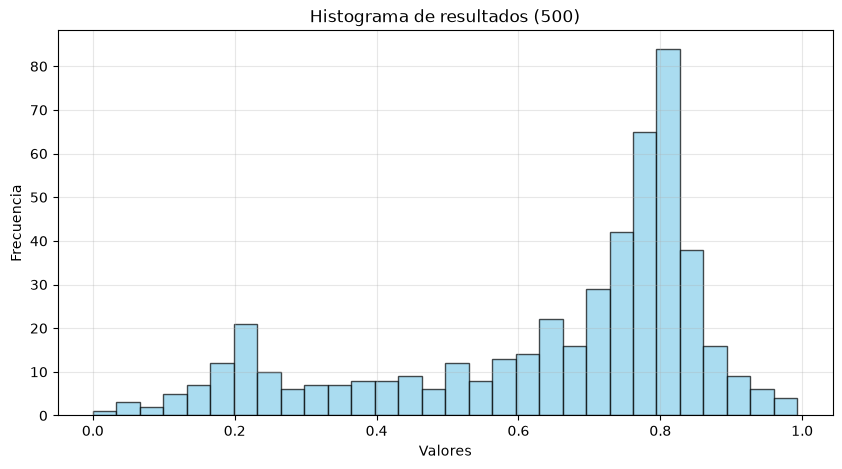

In [8]:
csv_file = r'C:\Users\playe\Documents\Trabajos\TFG-RAG-VDB\src\Resulsts\resultados_rag_500.csv'
df = pd.read_csv(csv_file)
fig, ax = plt.subplots(figsize=(10, 5))
ax.hist(df['Nota_Correctness'], bins=30, color='skyblue', edgecolor='black', alpha=0.7)
ax.set_xlabel('Valores')
ax.set_ylabel('Frecuencia')
ax.set_title('Histograma de resultados (500)')
ax.grid(True, alpha=0.3)
#fig.savefig('Histogram_500.png', dpi=300, bbox_inches='tight')

plt.show()